In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using GLMakie
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [3]:
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:50]

50-element Vector{SVector{3, Float64}}:
 [0.5120758147632092, 0.43691283053439967, 0.1702074237942628]
 [0.30154387153856066, 0.15233443457028006, 0.6794309715042275]
 [0.4245322417127253, 0.2748915895418125, 0.6415222287772103]
 [0.2628479558070017, 0.43703984002495355, 0.474520559721917]
 [0.08605720964029384, 0.6580203559357005, 0.7591589685236246]
 [0.8500030840327085, 0.6900659205901177, 0.48496789217853853]
 [0.15242185420541587, 0.7690863599186938, 0.9445134943683283]
 [0.17560134430298935, 0.22518325086671986, 0.05524788562648675]
 [0.7341425597495818, 0.3893175313213514, 0.19119846822126252]
 [0.10330141221288913, 0.05604843943240723, 0.39741503476664763]
 ⋮
 [0.44623638205356353, 0.20162893598821674, 0.8984551524679018]
 [0.6600462879658223, 0.1413286804533923, 0.5514943588680217]
 [0.5266292355006416, 0.4517930544331207, 0.429970850713577]
 [0.6853496630313346, 0.3559144797251601, 0.8552473229453196]
 [0.6895271332877665, 0.9149871864232615, 0.7896184564354407]
 [0.028935265

In [4]:
coords, tets = TesselationCore.tesselate(points3d)

([0.5120758147632092 0.30154387153856066 … 0.8866586472210479 0.009512028548885332; 0.43691283053439967 0.15233443457028006 … 0.18149615831479737 0.8340754475918473; 0.1702074237942628 0.6794309715042275 … 0.7790510560433366 0.7884241951761674], Int32[4 21 30 44; 19 8 12 35; … ; 37 3 43 32; 43 3 44 32])

In [5]:
plex = coords[:,tets[5,:]]'
point = Vector([1.,1.,1.])
point2 = Vector([0.14,0.88,0.56])

3-element Vector{Float64}:
 0.14
 0.88
 0.56

# Checking Belonging Speeds

In [6]:
"""
    intersection(p::Vector{Float64}, simplex)

Check whether the point `p` is contained in the simplex.

!! Function taken from PhaseSpaceDTFE implementation by Job Feldbrugge & Benjamin Hertzsch

"""
function intersection(p::Vector{Float64}, simplex)
    @inbounds barry = inv(@view(simplex[2:end,:])' .- @view(simplex[1,:])) * (p .- @view(simplex[1,:]))
    return all(barry .>= 0) & all(barry .<= 1) & (sum(barry) <= 1.)
end



function intersectionFast(p::Vector{Float64}, simplex)
    @inbounds begin
        v1 = view(simplex, 1, :) # first point in simplex
        A  = transpose(@view(simplex[2:end, :])) .- v1 # vector from first to each other point
        barry = A \ (p .- v1) #barry *A = p-v1
    end # barry -> linear compbination of other vertices to make the position of p
    s = sum(barry) 
    return all(barry .>= 0) && s <= 1.0 && all(barry .<= 1.0)  # conditions on barry for p to be inside
end


"""attempt to speed things up even more with StaticArrays"""
@inline function intersection3D(p::SVector{3, Float64}, simplex::SMatrix{4, 3, Float64})
    @inbounds begin
        v1, v2, v3, v4 = simplex[1, :], simplex[2, :], simplex[3, :], simplex[4, :]
        a = v2 - v1 
        b = v3 - v1 # distances from v1 to each vertex and p
        c = v4 - v1
        r = p - v1

        detA = dot(a, cross(b, c))  # Cramer's rule to make things faster
        x1 = dot(r, cross(b, c)) / detA
        x2 = dot(r, cross(c, a)) / detA
        x3 = dot(r, cross(a, b)) / detA
    end

    s = x1 + x2 + x3
    return (x1 >= 0) & (x2 >= 0) & (x3 >= 0) & (s <= 1)
end



function intersection3D(p::Vector{Float64}, simplex)
    sP = SVector{3}(p)
    sSimp = SMatrix{4,3}(simplex)
    return intersection3D(sP, sSimp)
end

intersection3D (generic function with 2 methods)

In [7]:
p = rand(3)
simplex = [rand(3)' for _ in 1:4] |> x -> reduce(vcat, x)


4×3 Matrix{Float64}:
 0.0732624  0.424234  0.938306
 0.546774   0.458605  0.314289
 0.839591   0.738958  0.641755
 0.0575807  0.267071  0.194852

In [8]:
println("Verifying all return same result:")
@assert intersection(p, simplex) == intersectionFast(p, simplex) ==
        intersection3D(p, simplex)

Verifying all return same result:


In [9]:
println("Benchmarking each version:\n")

@btime intersection($p, $simplex)
@btime intersectionFast($p, $simplex)
@btime intersection3D($p, $simplex)

Benchmarking each version:

  1.380 μs (19 allocations: 2.36 KiB)
  796.907 ns (13 allocations: 624 bytes)
  20.060 ns (0 allocations: 0 bytes)


false

In [10]:
println("Benchmarking each version backwards: \n")

@btime intersection3D($p, $simplex)
@btime intersectionFast($p, $simplex)
@btime intersection($p, $simplex)


Benchmarking each version backwards: 

  19.960 ns (0 allocations: 0 bytes)
  793.814 ns (13 allocations: 624 bytes)
  1.380 μs (19 allocations: 2.36 KiB)


false

Static implementation is insanely fast. If this works out in the end product, I will inform Job.

We have a factor of 70 improvement at least in this lookup. If I was a good programmer I might check if the whole algorithm is affected by this or it's some other thing that is the weakest link, but instead I think I'll declare victory.

# Benchmarking sorted search vs naive search

In [11]:
simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])
simplices[5] == plex

true

In [12]:
function exhaustiveSearch(p::Vector{Float64}, simplices::Vector)
    matches = Int[]
    for (i, s) in pairs(simplices)
        if intersection3D(p, s)
            push!(matches, i)
        end
    end
    return matches
end

function earlyStopSearch(p::Vector{Float64}, simplices::Vector)
    for (i, s) in pairs(simplices)
        if intersection3D(p, s)
            return i
        end
    end
    return nothing
end

function jobSearch(p::Vector{Float64}, simplices::Vector) # I know what job does is probably smarter than mine, but we check
    @inbounds filter(s -> intersection3D(p, s, simplices))
end

function geomSearch(p::Vector{Float64}, simplices::Vector) # my guess is 6/7 cases the closest is best
    # Precompute distances from centroids
    dists = [(i, norm(mean(s; dims=1)' .- p)) for (i, s) in pairs(simplices)] # i so we can remember original ordering
    sorted = sort(dists, by = x -> x[2])  

    for (i, _) in sorted
        if intersection3D(p, simplices[i])
            return i
        end
    end
    return nothing
end


geomSearch (generic function with 1 method)

In [13]:
@btime exhaustiveSearch(point2,simplices)
@btime earlyStopSearch(point2,simplices)
@btime jobSearch(point2,simplices)
@btime geomSearch(point2,simplices)

  10.200 μs (2 allocations: 128 bytes)
  1.130 μs (0 allocations: 0 bytes)
  622.989 ns (2 allocations: 64 bytes)
  331.100 μs (3657 allocations: 181.88 KiB)


24

It's not surprising the allocation takes forever. My question is if that becomes justified at large enough search ranges.

In [14]:
funcs = [exhaustiveSearch,earlyStopSearch,jobSearch,geomSearch]

4-element Vector{Function}:
 exhaustiveSearch (generic function with 1 method)
 earlyStopSearch (generic function with 1 method)
 jobSearch (generic function with 1 method)
 geomSearch (generic function with 1 method)

In [15]:
function trailFuncts(points, simplices)
    times = []

    for point in points
        time = Float64[]

        for f in funcs
            bench = @benchmarkable $f(point, simplices)
            stats = run(bench)
            push!(time,mean(stats).time)
        end

        push!(times,time)
    end
    return times
end


trailFuncts([point,point2],simplices)

2-element Vector{Any}:
 [10405.5, 10706.91, 809.75, 425433.7]
 [10391.05, 11352.02, 859.52, 504319.887697805]

In [16]:
N = 10
points = [rand(3) for i in 1:N]

10-element Vector{Vector{Float64}}:
 [0.4663062392557411, 0.09461645841566135, 0.08626268846323859]
 [0.4714789082184897, 0.24055784518361867, 0.6083183932602229]
 [0.9296835582194091, 0.1688341837951295, 0.9377051029797304]
 [0.21712638913489846, 0.5038810728916163, 0.30770735459105747]
 [0.6903565891509852, 0.05232433069639553, 0.2685146400193198]
 [0.8424533593714878, 0.13204230214144208, 0.06692937974812141]
 [0.2346057781595967, 0.4539490523517854, 0.8124145716070674]
 [0.21934463588085018, 0.6911988953140247, 0.7022496170942724]
 [0.6089294205325233, 0.7900626956958017, 0.9428560434917904]
 [0.6997261981672885, 0.011029608978411098, 0.3437200050681952]

In [80]:
X = [10,50,300,1000,10000]

errs = []
times = []

for x in X
    coords, tets = TesselationCore.tesselate([TesselationCore.point3(@SVector rand(3)) for _ in 1:x])
    simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])
    t = trailFuncts(points,simplices)

    push!(times,mean(t))
    push!(errs,std(t))
end

In [107]:
times

5-element Vector{Any}:
 [910.2299999999999, 926.4160000000002, 812.8789999999999, 34494.799]
 [10128.252, 10313.844999999998, 808.942, 406590.878]
 [85187.851, 86682.753, 826.734, 3.282007805033367e6]
 [339431.73400000005, 340336.154, 951.8779999999999, 1.4609239408115914e7]
 [3.7961612721640556e6, 3.8311542152394457e6, 967.747, 1.650364802580645e8]

In [108]:
labels =["exhaustive","first","job","geom"]
p = Plots.plot(yscale=:log10)
for i in 1:4

    e = [errs[j][i] for j in 1:5]
    y = [times[j][i] for j in 1:5]


    Plots.plot!(X,y , yerr = e, label = labels[i])
end


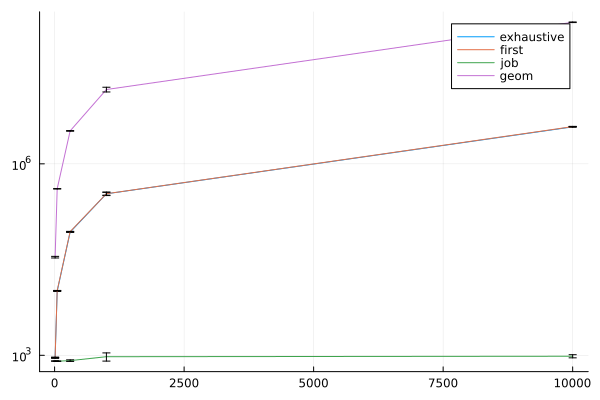

In [109]:
p

Geometric search is generally worse and has no sign of improvement. At least if it is getting better with larger sets, it's doing it so slowly, that it doesn't matter. 


Geom is worse in retrospect. I'll adapt Job's thing tomorrow.